# MR4010 Navegación Autónoma

## Redes Neuronales con Keras

### Redes Neuronales para Clasificación Multiclase

En este notebook se construye una red neuronal usando Keras para resolver un problema de clasificación multiclase.

El dataset será generado artificialmente usando `make_blobs`, creando cinco grupos o clases diferentes.

El objetivo es entrenar una red neuronal que pueda clasificar correctamente cada punto en una de las cinco clases.

Lee el capítulo 5 del libro de texto:

Venturi, L. y Korda, K. (2020). Hands-On Vision and Behavior For Self-Driving Cars. Packt Publishing. Disponible en: https://learning.oreilly.com/library/view/hands-on-vision-and/9781800203587/B16322_FM_Final_NM_ePUB.xhtml


Ranjan, S. y Senthamilarasu S.(2020). Applied Deep Learning and Computer Vision for Self-Driving Cars. Packt Publishing Ltd.
https://learning.oreilly.com/library/view/applied-deep-learning/9781838646301/?sso_link=yes&sso_link_from=ITESMLinks to an external site.



## Paso 1 - Instalacion de pytorch paar correr en GPU, para esto correr en terminal
Paso a paso

python -m pip install --upgrade pip setuptools wheel

python -m pip install --force-reinstall --no-cache-dir typing-extensions==4.12.2

python -m pip install --no-cache-dir `
  torch==2.7.1+cu128 `
  torchvision==0.22.1+cu128 `
  torchaudio==2.7.1+cu128 `
  --index-url https://download.pytorch.org/whl/cu128

![image.png](attachment:image.png)

In [1]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Torch: 2.7.1+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Capability: (12, 0)


# Paso 2 — Cargar bibliotecas

Explicación rápida:

numpy: nos ayuda con matrices, vectores y operaciones matemáticas.

matplotlib: nos ayuda a graficar los datos y la frontera de decisión.

%matplotlib inline: permite que las gráficas aparezcan dentro del notebook.

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from matplotlib.colors import ListedColormap

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

print(r'Tensor flow: ',tf.__version__)

Tensor flow:  2.21.0


## Paso 3 - Cargar dataset

### Crear el dataset

Se crean cinco grupos de datos usando `make_blobs`.

Cada grupo representa una clase diferente.

Parámetros importantes:

- `n_samples`: número total de puntos.
- `centers`: coordenadas de los centros de cada clase.
- `cluster_std`: dispersión de los puntos alrededor del centro.
- `random_state`: semilla para reproducibilidad.

In [8]:
# Definimos el número de puntos
n_pts = 5000

# Definimos los centros de las 5 clases
centers = [[-1, 1], [-1, -1], [1, -1], [1, 1], [0, 0]]

# Creamos el dataset
X, y = datasets.make_blobs(
    n_samples=n_pts,
    random_state=123,
    centers=centers,
    cluster_std=0.4
)

# Revisamos las dimensiones
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases disponibles:", np.unique(y))

Shape de X: (5000, 2)
Shape de y: (5000,)
Clases disponibles: [0 1 2 3 4]


## Paso 4. Visualizar el dataset

Como el dataset tiene dos variables de entrada, podemos graficarlo en un plano 2D.

Cada color representa una clase diferente.

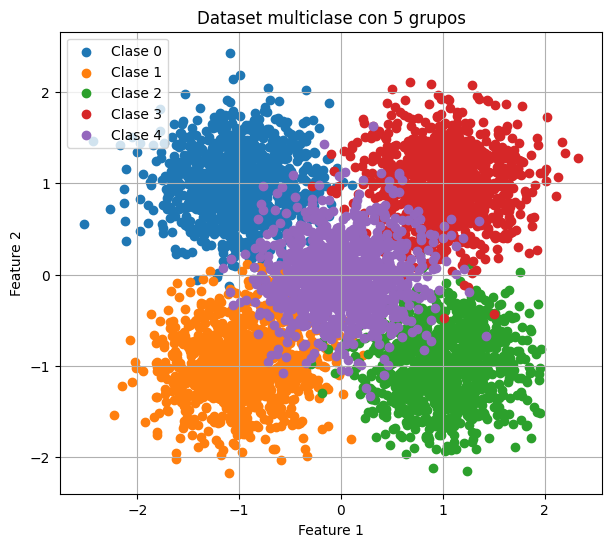

In [9]:
# Graficamos cada clase por separado

plt.figure(figsize=(7, 6))

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Clase 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Clase 1")
plt.scatter(X[y == 2, 0], X[y == 2, 1], label="Clase 2")
plt.scatter(X[y == 3, 0], X[y == 3, 1], label="Clase 3")
plt.scatter(X[y == 4, 0], X[y == 4, 1], label="Clase 4")

plt.title("Dataset multiclase con 5 grupos")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Paso 5 - Convertir las etiquetas a One-Hot Encoding

Para clasificación multiclase con Keras, las etiquetas se convierten a formato One-Hot Encoding.

Ejemplo:

Clase original:

```text
2### 2. Selección de features y etiqueta

Para simplificar la visualización, se seleccionan solo dos variables:

- `mean radius`
- `mean texture`

La etiqueta será la columna `target`.

In [10]:
## Celda Código 4


# Convertimos las etiquetas numéricas a One-Hot Encoding

y_cat = to_categorical(y, num_classes=5)

# Mostramos ejemplos
print("Etiquetas originales:")
print(y[:10])

print("\nEtiquetas en One-Hot Encoding:")
print(y_cat[:10])

Etiquetas originales:
[4 4 4 4 0 1 2 2 2 3]

Etiquetas en One-Hot Encoding:
[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]]


## Paso 6 - Division de entrenamiento y prueba

### División Train/Test

Se divide el dataset en:
- 80% entrenamiento
- 20% prueba

In [45]:
# División Train/Test usando One-Hot Encoding

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,   # <- IMPORTANTE
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 2)
X_test: (1000, 2)
y_train: (4000, 5)
y_test: (1000, 5)


## Paso 8 - Creacion de la red neuronal

### Crear la red neuronal

La red tendrá:

- 2 entradas, porque el dataset tiene dos features.
- Una capa oculta con 32 neuronas y activación ReLU.
- Una capa de salida con 5 neuronas y activación Softmax.

La función Softmax convierte las salidas del modelo en probabilidades para cada clase.

In [46]:
# Creamos el modelo secuencial

model = Sequential()

# Capa oculta
model.add(Dense(
    units=32,
    activation='relu',
    input_shape=(2,)
))

# Capa de salida
model.add(Dense(
    units=5,
    activation='softmax'
))

# Compilamos el modelo
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostramos el resumen del modelo
model.summary()

d:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

## Paso 10 - Entrenamienro del modelo

### Entrenar el modelo

Durante el entrenamiento, el modelo ajusta sus pesos para reducir el error.

Parámetros usados:

- `epochs`: número de veces que el modelo ve todo el dataset.
- `batch_size`: número de muestras procesadas antes de actualizar los pesos.
- `validation_data`: conjunto usado para validar el modelo después de cada época.

In [47]:
# Entrenamos el modelo

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=50,
    verbose=1
)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8275 - loss: 0.5579 - val_accuracy: 0.9300 - val_loss: 0.2205
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9323 - loss: 0.1985 - val_accuracy: 0.9350 - val_loss: 0.1899
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9308 - loss: 0.1865 - val_accuracy: 0.9340 - val_loss: 0.1873
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9293 - loss: 0.1868 - val_accuracy: 0.9330 - val_loss: 0.1836
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9298 - loss: 0.1872 - val_accuracy: 0.9290 - val_loss: 0.1839
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9310 - loss: 0.1854 - val_accuracy: 0.9350 - val_loss: 0.1840
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9323 - loss: 0.1840 - val_accuracy: 0.9330 - val_loss: 0.1830
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9302 - loss: 0.1850 - val_accuracy: 0.9270 - v

## Paso 11 - resumen del modelo

### Arquitectura del Modelo

In [48]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 524 (2.05 KB)

## Paso 12 - Graficar exactitud

### Evolución de la exactitud

Se observa cómo mejora el accuracy
durante el entrenamiento.

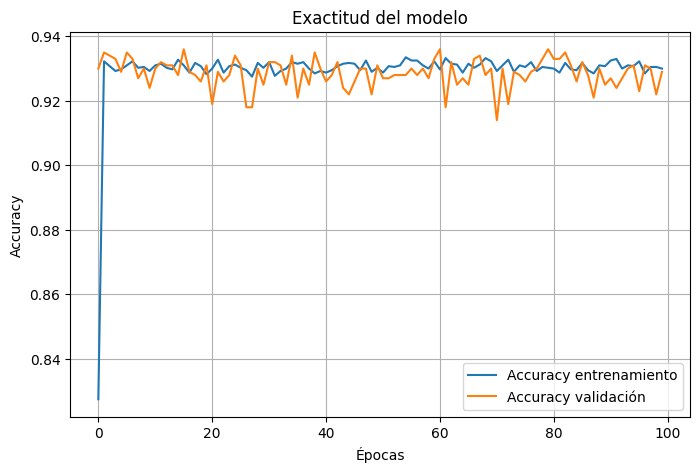

In [49]:
# Graficamos la exactitud de entrenamiento y validación

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy validación')

plt.title('Exactitud del modelo')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Paso 13 - Graficar perdida de entrenamiento y validacion

### Evolución del error

Se visualiza cómo disminuye la función de pérdida.

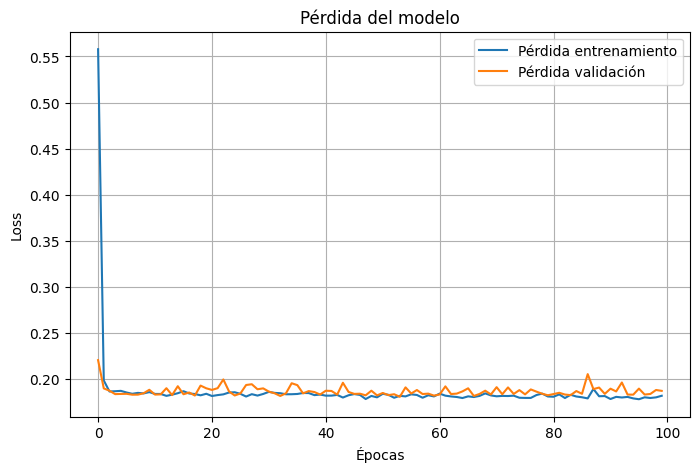

In [50]:
# Graficamos la pérdida de entrenamiento y validación

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')

plt.title('Pérdida del modelo')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Paso 14 - evaluar el modelo

###  Evaluar el modelo

Evaluamos el modelo usando el conjunto de prueba.

Esto nos da la pérdida final y la exactitud final del modelo.### Visualización de resultados

### Frontera de Clasificación

Se visualiza la frontera de decisión aprendida
por la red neuronal.

In [51]:
# Evaluamos el modelo

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Pérdida en prueba:", loss)
print("Accuracy en prueba:", accuracy)

Pérdida en prueba: 0.18718039989471436
Accuracy en prueba: 0.9290000200271606


## Realizar predicciones

El modelo entrega una probabilidad para cada clase.

Usamos `argmax()` para seleccionar la clase con mayor probabilidad.

In [52]:
# Obtenemos las predicciones del modelo

y_pred_prob = model.predict(X_test)

# Convertimos probabilidades a clases
y_pred = np.argmax(y_pred_prob, axis=1)

# Convertimos y_test de One-Hot a clase numérica
y_test_classes = np.argmax(y_test, axis=1)

print("Primeras predicciones:")
print(y_pred[:20])

print("\nClases reales:")
print(y_test_classes[:20])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Primeras predicciones:
[1 3 0 2 4 0 0 1 0 2 2 1 0 1 2 4 0 2 1 3]

Clases reales:
[1 3 0 2 2 0 0 1 0 2 2 1 0 0 2 4 0 2 1 3]


## Paso 15 - Matriz de confusion

In [53]:
# Calculamos la matriz de confusión

cm = confusion_matrix(y_test_classes, y_pred)

print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[191   2   0   1   6]
 [  1 187   0   0  12]
 [  0   1 192   0   7]
 [  1   0   0 190   9]
 [  4   4  12  11 169]]


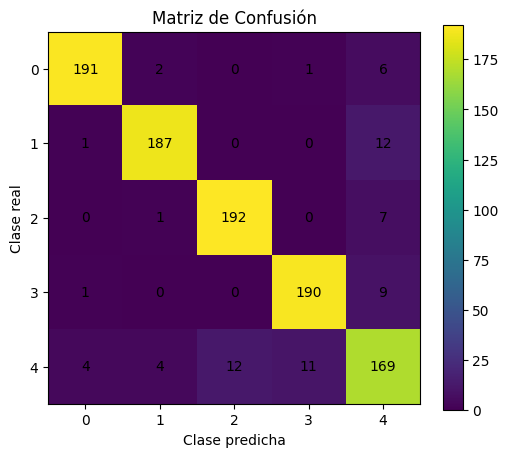

In [54]:
# Visualizamos la matriz de confusión

plt.figure(figsize=(6, 5))

plt.imshow(cm)
plt.title("Matriz de Confusión")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Paso 18 - Reporte de clasificacion

### Reporte de clasificación

El reporte de clasificación muestra:

- Precision
- Recall
- F1-score
- Support

Esto permite evaluar el desempeño del modelo por clase.

In [55]:
# Mostramos el reporte de clasificación

print(classification_report(y_test_classes, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       200
           1       0.96      0.94      0.95       200
           2       0.94      0.96      0.95       200
           3       0.94      0.95      0.95       200
           4       0.83      0.84      0.84       200

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



### Visualizar la clasificación del modelo

Ahora graficamos los puntos del conjunto de prueba usando la clase predicha por el modelo.

Esto permite observar visualmente cómo está clasificando la red neuronal.

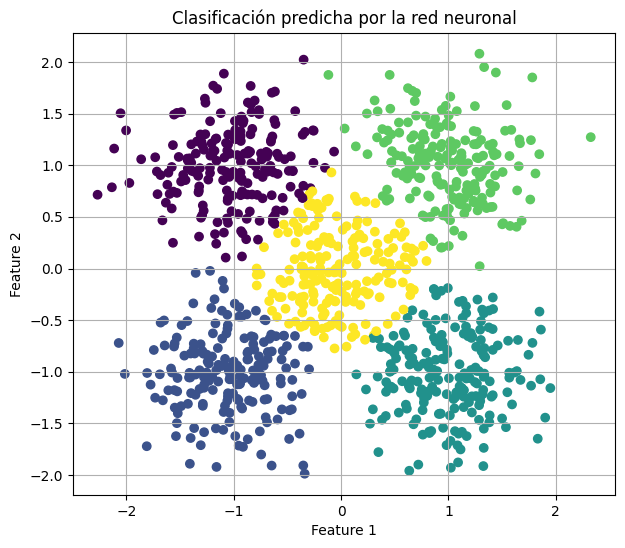

In [56]:
# Graficamos las predicciones del modelo

plt.figure(figsize=(7, 6))

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)

plt.title("Clasificación predicha por la red neuronal")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

### Comparación entre clases reales y clases predichas

En esta sección se comparan visualmente las clases reales contra las clases predichas.

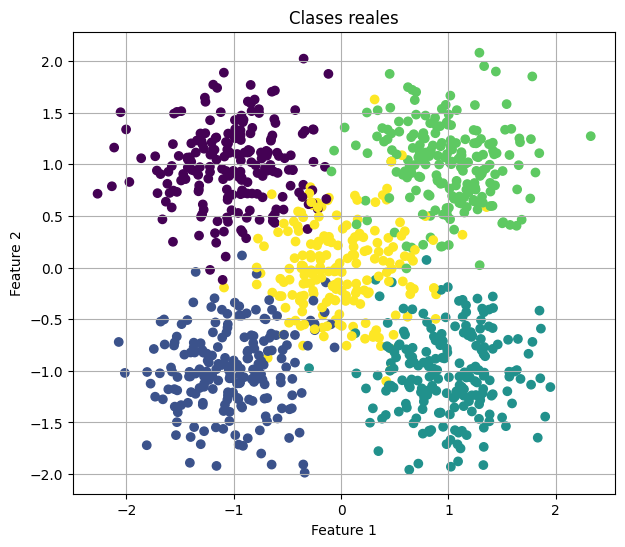

In [57]:
# Gráfica de clases reales

plt.figure(figsize=(7, 6))

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test_classes)

plt.title("Clases reales")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

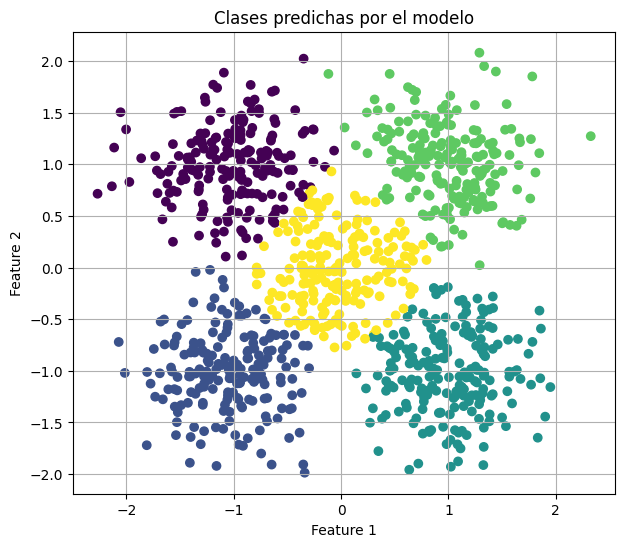

In [58]:
# Gráfica de clases predichas

plt.figure(figsize=(7, 6))

plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)

plt.title("Clases predichas por el modelo")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

## Paso 19 - Verificar la clasificación de manera gráfica

Ahora se visualiza la frontera de decisión del modelo.

La frontera de decisión muestra qué región del plano pertenece a cada clase según la red neuronal.

In [59]:
# Función para graficar la frontera de decisión multiclase

def plot_multiclass_decision_boundary(X, y, model):
    
    # Creamos un rango de valores para X1 y X2
    x_span = np.linspace(min(X[:, 0]) - 1, max(X[:, 0]) + 1, 100)
    y_span = np.linspace(min(X[:, 1]) - 1, max(X[:, 1]) + 1, 100)
    
    # Creamos una malla de puntos
    xx, yy = np.meshgrid(x_span, y_span)
    
    # Convertimos la malla a pares de coordenadas
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    # El modelo predice una clase para cada punto de la malla
    pred_func = np.argmax(model.predict(grid, verbose=0), axis=1)
    
    # Reorganizamos las predicciones para graficarlas
    z = pred_func.reshape(xx.shape)
    
    # Graficamos las regiones de clasificación
    plt.contourf(xx, yy, z, alpha=0.4)

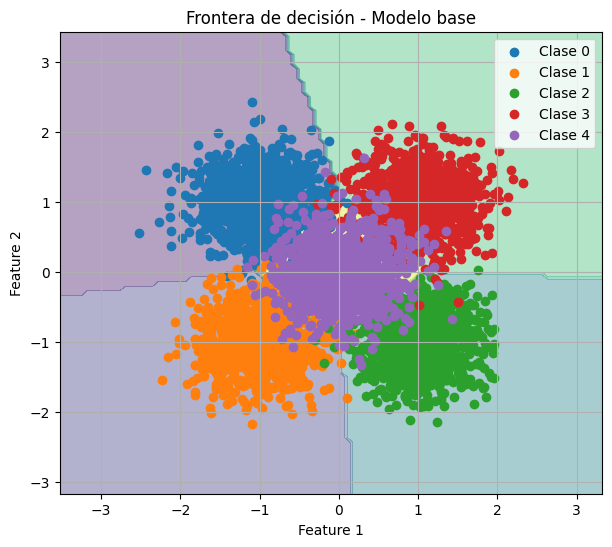

In [60]:
# Graficamos la frontera de decisión junto con los datos originales

plt.figure(figsize=(7, 6))

plot_multiclass_decision_boundary(X, y_cat, model)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Clase 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Clase 1")
plt.scatter(X[y == 2, 0], X[y == 2, 1], label="Clase 2")
plt.scatter(X[y == 3, 0], X[y == 3, 1], label="Clase 3")
plt.scatter(X[y == 4, 0], X[y == 4, 1], label="Clase 4")

plt.title("Frontera de decisión - Modelo base")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Paso 20 - Modelo Mejorado - Red Neuronal Profunda

## Modificación 1

En esta modificación se agrega una segunda capa oculta de 16 neuronas.

El objetivo es observar si una red con mayor profundidad puede mejorar la clasificación.

In [34]:
# Creamos un nuevo modelo con dos capas ocultas

model_mod_1 = Sequential()

model_mod_1.add(Dense(
    units=32,
    activation='relu',
    input_shape=(2,)
))

model_mod_1.add(Dense(
    units=16,
    activation='relu'
))

model_mod_1.add(Dense(
    units=5,
    activation='softmax'
))

model_mod_1.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mod_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 709 (2.77 KB)

 Trainable params: 709 (2.77 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Entrenamos el modelo modificado 1

history_mod_1 = model_mod_1.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=50,
    verbose=1
)

# Evaluamos el modelo
scores_mod_1 = model_mod_1.evaluate(X_test, y_test, verbose=0)

print("Test loss:", scores_mod_1[0])
print("Test accuracy:", scores_mod_1[1])

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8495 - loss: 0.4503 - val_accuracy: 0.9290 - val_loss: 0.1914
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9258 - loss: 0.2009 - val_accuracy: 0.9280 - val_loss: 0.1900
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9298 - loss: 0.1977 - val_accuracy: 0.9270 - val_loss: 0.1930
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9287 - loss: 0.1933 - val_accuracy: 0.9140 - val_loss: 0.2025
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9275 - loss: 0.1927 - val_accuracy: 0.9320 - val_loss: 0.1870
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9290 - loss: 0.1890 - val_accuracy: 0.9200 - val_loss: 0.1912
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9287 - loss: 0.1918 - val_accuracy: 0.9140 - val_loss: 0.1955
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9280 - loss: 0.1931 - val_accuracy: 0.9170 - v

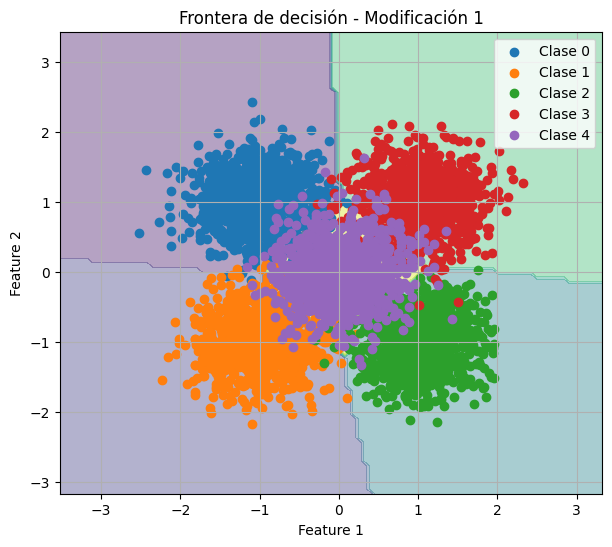

In [36]:
# Frontera de decisión para la modificación 1

plt.figure(figsize=(7, 6))

plot_multiclass_decision_boundary(X, y_cat, model_mod_1)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Clase 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Clase 1")
plt.scatter(X[y == 2, 0], X[y == 2, 1], label="Clase 2")
plt.scatter(X[y == 3, 0], X[y == 3, 1], label="Clase 3")
plt.scatter(X[y == 4, 0], X[y == 4, 1], label="Clase 4")

plt.title("Frontera de decisión - Modificación 1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Paso 21 - Entrenamiento del modelo profundo

### Modificación 2

En esta modificación se agrega otra capa oculta respecto a la modificación anterior.

La arquitectura queda con dos capas ocultas:

- Primera capa oculta: 32 neuronas.
- Segunda capa oculta: 16 neuronas.
- Capa de salida: 5 neuronas con Softmax.

In [37]:
# Creamos el modelo de la modificación 2

model_mod_2 = Sequential()

model_mod_2.add(Dense(
    units=32,
    activation='relu',
    input_shape=(2,)
))

model_mod_2.add(Dense(
    units=16,
    activation='relu'
))

model_mod_2.add(Dense(
    units=5,
    activation='softmax'
))

model_mod_2.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mod_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 709 (2.77 KB)

 Trainable params: 709 (2.77 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Entrenamos el modelo modificado 2

history_mod_2 = model_mod_2.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=50,
    verbose=1
)

# Evaluamos el modelo
scores_mod_2 = model_mod_2.evaluate(X_test, y_test, verbose=0)

print("Test loss:", scores_mod_2[0])
print("Test accuracy:", scores_mod_2[1])

Epoch 1/100


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8175 - loss: 0.4986 - val_accuracy: 0.9240 - val_loss: 0.2003
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9273 - loss: 0.1968 - val_accuracy: 0.9260 - val_loss: 0.1941
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9305 - loss: 0.1986 - val_accuracy: 0.9300 - val_loss: 0.1850
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9283 - loss: 0.1957 - val_accuracy: 0.9220 - val_loss: 0.2048
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9293 - loss: 0.1892 - val_accuracy: 0.9240 - val_loss: 0.1929
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9308 - loss: 0.1891 - val_accuracy: 0.9270 - val_loss: 0.2009
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9283 - loss: 0.1973 - val_accuracy: 0.9280 - val_loss: 0.1913
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9305 - loss: 0.1915 - val_accuracy: 0.9250 - val_loss: 0.1

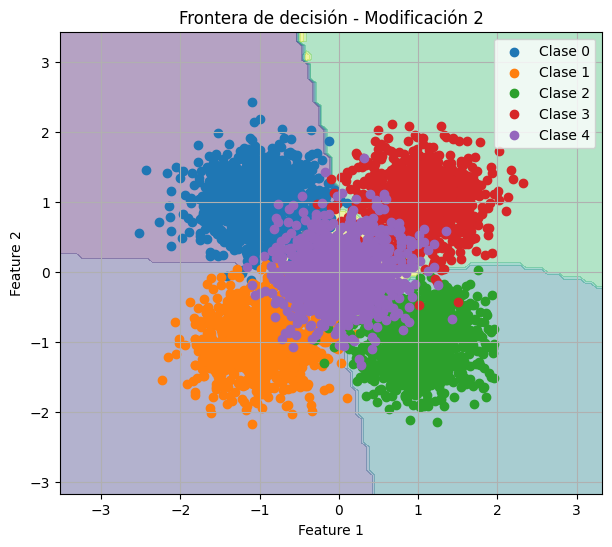

In [39]:
# Frontera de decisión para la modificación 2

plt.figure(figsize=(7, 6))

plot_multiclass_decision_boundary(X, y_cat, model_mod_2)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Clase 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Clase 1")
plt.scatter(X[y == 2, 0], X[y == 2, 1], label="Clase 2")
plt.scatter(X[y == 3, 0], X[y == 3, 1], label="Clase 3")
plt.scatter(X[y == 4, 0], X[y == 4, 1], label="Clase 4")

plt.title("Frontera de decisión - Modificación 2")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Paso 22 - Modelo Profundo optimizacion 3

### Modificación 3

En esta modificación se mantiene una sola capa oculta, pero se incrementa el número de neuronas de 32 a 64.

El objetivo es observar si una capa más ancha mejora la capacidad del modelo.

In [40]:
# Creamos el modelo de la modificación 3

model_mod_3 = Sequential()

model_mod_3.add(Dense(
    units=64,
    activation='relu',
    input_shape=(2,)
))

model_mod_3.add(Dense(
    units=5,
    activation='softmax'
))

model_mod_3.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mod_3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 517 (2.02 KB)

 Trainable params: 517 (2.02 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Entrenamos el modelo modificado 3

history_mod_3 = model_mod_3.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=50,
    verbose=1
)

# Evaluamos el modelo
scores_mod_3 = model_mod_3.evaluate(X_test, y_test, verbose=0)

print("Test loss:", scores_mod_3[0])
print("Test accuracy:", scores_mod_3[1])

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8752 - loss: 0.4237 - val_accuracy: 0.9250 - val_loss: 0.1922
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9280 - loss: 0.1883 - val_accuracy: 0.9320 - val_loss: 0.1839
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9280 - loss: 0.1890 - val_accuracy: 0.9310 - val_loss: 0.1858
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9277 - loss: 0.1881 - val_accuracy: 0.9340 - val_loss: 0.1884
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9312 - loss: 0.1880 - val_accuracy: 0.9200 - val_loss: 0.2006
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9283 - loss: 0.1897 - val_accuracy: 0.9280 - val_loss: 0.1869
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9285 - loss: 0.1833 - val_accuracy: 0.9350 - val_loss: 0.1825
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9310 - loss: 0.1859 - val_accuracy: 0.9270 - v

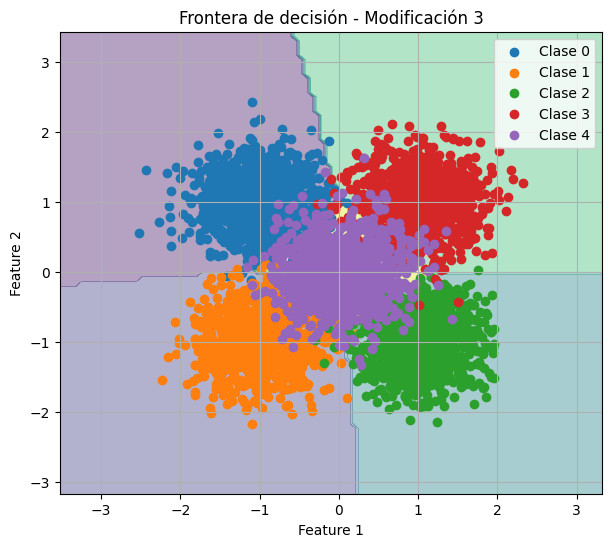

In [42]:
# Frontera de decisión para la modificación 3

plt.figure(figsize=(7, 6))

plot_multiclass_decision_boundary(X, y_cat, model_mod_3)

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Clase 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Clase 1")
plt.scatter(X[y == 2, 0], X[y == 2, 1], label="Clase 2")
plt.scatter(X[y == 3, 0], X[y == 3, 1], label="Clase 3")
plt.scatter(X[y == 4, 0], X[y == 4, 1], label="Clase 4")

plt.title("Frontera de decisión - Modificación 3")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

## Paso 23 - Comparacion final de modelos

### Comparación final de modelos

Se comparan los resultados de los cuatro modelos:

- Modelo base.
- Modificación 1.
- Modificación 2.
- Modificación 3.### Frontera de Decisión Mejorada

Ahora la red neuronal puede aprender
la forma curva del dataset.

In [61]:
# Evaluamos nuevamente todos los modelos

scores_base = model.evaluate(X_test, y_test, verbose=0)
scores_mod_1 = model_mod_1.evaluate(X_test, y_test, verbose=0)
scores_mod_2 = model_mod_2.evaluate(X_test, y_test, verbose=0)
scores_mod_3 = model_mod_3.evaluate(X_test, y_test, verbose=0)

print("Modelo base")
print("Loss:", scores_base[0])
print("Accuracy:", scores_base[1])

print("\nModificación 1")
print("Loss:", scores_mod_1[0])
print("Accuracy:", scores_mod_1[1])

print("\nModificación 2")
print("Loss:", scores_mod_2[0])
print("Accuracy:", scores_mod_2[1])

print("\nModificación 3")
print("Loss:", scores_mod_3[0])
print("Accuracy:", scores_mod_3[1])

Modelo base
Loss: 0.18718039989471436
Accuracy: 0.9290000200271606

Modificación 1
Loss: 0.19235271215438843
Accuracy: 0.9309999942779541

Modificación 2
Loss: 0.19476628303527832
Accuracy: 0.9259999990463257

Modificación 3
Loss: 0.18772277235984802
Accuracy: 0.9330000281333923


## Paso 24 - Reporte final

### Conclusiones finales

La clasificación multiclase requiere una capa de salida con una neurona por cada clase.

En este ejercicio se utilizaron cinco clases, por lo tanto la capa final tiene cinco neuronas.

La función de activación Softmax permite convertir la salida del modelo en probabilidades para cada clase.

Al comparar las modificaciones, se puede observar cómo cambiar la arquitectura afecta el desempeño del modelo.

Agregar más capas o más neuronas puede mejorar la capacidad del modelo, pero también puede aumentar el riesgo de sobreajuste.

La frontera de decisión permite verificar visualmente cómo la red neuronal divide el espacio de características para clasificar cada punto.